In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('../data/ticket_classification.csv')

In [3]:
subject=df.iloc[0]['subject']

In [4]:
body=df.iloc[0]['body']

In [5]:
queue=df.iloc[0]['queue']
queue

'Technical Support'

In [6]:
ticket_type=df.iloc[0]['type']

In [7]:
priority=df.iloc[0]['priority']
priority

'high'

In [8]:
import re
import string
import pandas as pd
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

from nltk.stem import WordNetLemmatizer

from nltk.corpus import stopwords

# for ML algorithms removing stopwords and lemmatization is required
def clean_text_ml(text):
    lemmatizer= WordNetLemmatizer()
    stop_words=set(stopwords.words('english'))
    if not isinstance(text, str):
        return ""

    # 1. Lowercase the text
    text = text.lower()

    # 2. Remove BOTH actual newlines and literal "\n" text strings
    text = text.replace("\n", " ").replace("\\n", " ").replace("\r", " ")

    # 3. Isolates punctuation marks with spaces
    text = re.sub(r"([.,!?():\"'])", r" \1 ", text)

    # 4. Remove extra spaces and squash down to a single clean space
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    cleaned_words = []

    for word in words:

        # Remove stopwords
        if word not in stop_words:

            # Lemmatize
            lemma_word = lemmatizer.lemmatize(word)

            cleaned_words.append(lemma_word)

    # Join back
    text = " ".join(cleaned_words)

    return text

[nltk_data] Downloading package wordnet to /Users/rishabh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/rishabh/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rishabh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
import joblib
import numpy as np
import pandas as pd

import shap
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier

In [10]:
# Load models
priority_model = joblib.load("../models/priority_xgb.pkl")

# Load encoders
priority_label_encoder = joblib.load("../models/priority_label_encoder.pkl")
queue_label_encoder = joblib.load("../models/queue_label_encoder.pkl")
type_label_encoder = joblib.load("../models/type_label_encoder.pkl")

# Load tfidf
tfidf = joblib.load("../models/tfidf_type.pkl")

In [11]:
sample_data = pd.DataFrame({
    "subject": [
        subject
    ],

    "body": [
        body
    ],

    "queue": [
        queue
    ],

    "type": [
        ticket_type
    ]
})

In [ ]:
sample_data["text"] = (
    sample_data["subject"].apply(clean_text_ml) + " " + sample_data["body"].apply(clean_text_ml)
)
sample_data.iloc[0]["text"]


'account disruption dear customer support team , writing report significant problem centralized account management portal , currently appears offline . outage blocking access account setting , leading substantial inconvenience . attempted log multiple time using different browser device , issue persists . could please provide update outage status estimated time resolution ? also , alternative way access manage account downtime ?'

In [14]:
sample_data["queue_encoded"] = queue_label_encoder.transform(
    sample_data["queue"]
)

sample_data["type_encoded"] = type_label_encoder.transform(
    sample_data["type"]
)

In [15]:
X_text = tfidf.transform(sample_data["text"])

In [16]:
X_cat = csr_matrix(
    sample_data[["queue_encoded", "type_encoded"]].values
)

X_final = hstack([X_text, X_cat])

In [17]:
tfidf_features = tfidf.get_feature_names_out().tolist()

feature_names = (
    tfidf_features
    + ["queue_encoded", "type_encoded"]
)

In [24]:
pred = priority_model.predict(X_final)
predicted_class=pred[0]

pred_label = priority_label_encoder.inverse_transform(pred)

print("Predicted Priority:", pred_label[0])

Predicted Priority: high


In [25]:
explainer = shap.TreeExplainer(priority_model)

shap_values = explainer.shap_values(X_final)

In [26]:
X_dense = pd.DataFrame(
    X_final.toarray(),
    columns=feature_names
)

In [27]:
queue_value = sample_data["queue"].iloc[0]
type_value = sample_data["type"].iloc[0]

X_dense.rename(
    columns={
        "queue_encoded": f"queue={queue_value}",
        "type_encoded": f"type={type_value}"
    },
    inplace=True
)

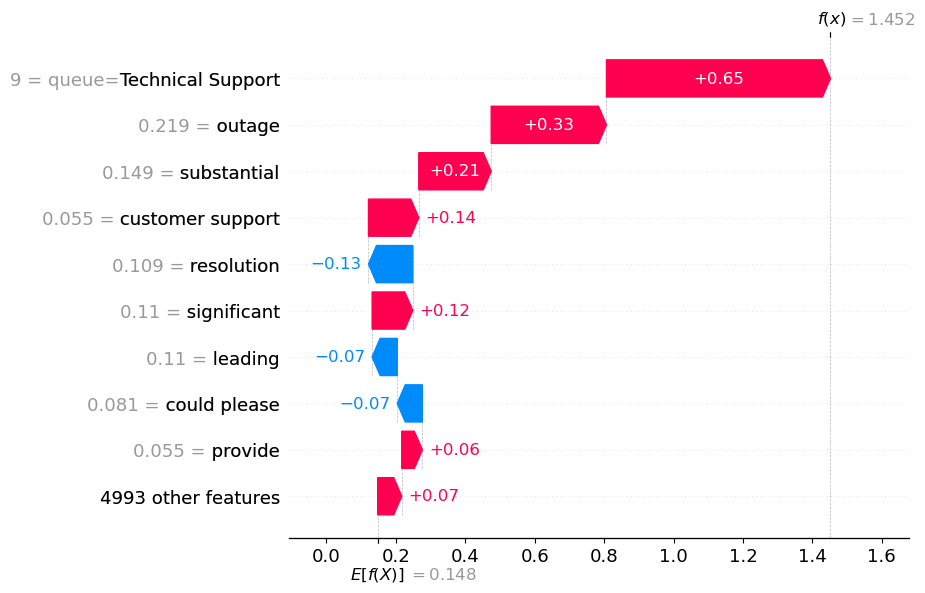

In [28]:
single_explanation = shap.Explanation(
    values=shap_values[0][:, predicted_class],
    base_values=explainer.expected_value[predicted_class],
    data=X_dense.iloc[0],
    feature_names=X_dense.columns
)

shap.plots.waterfall(single_explanation)

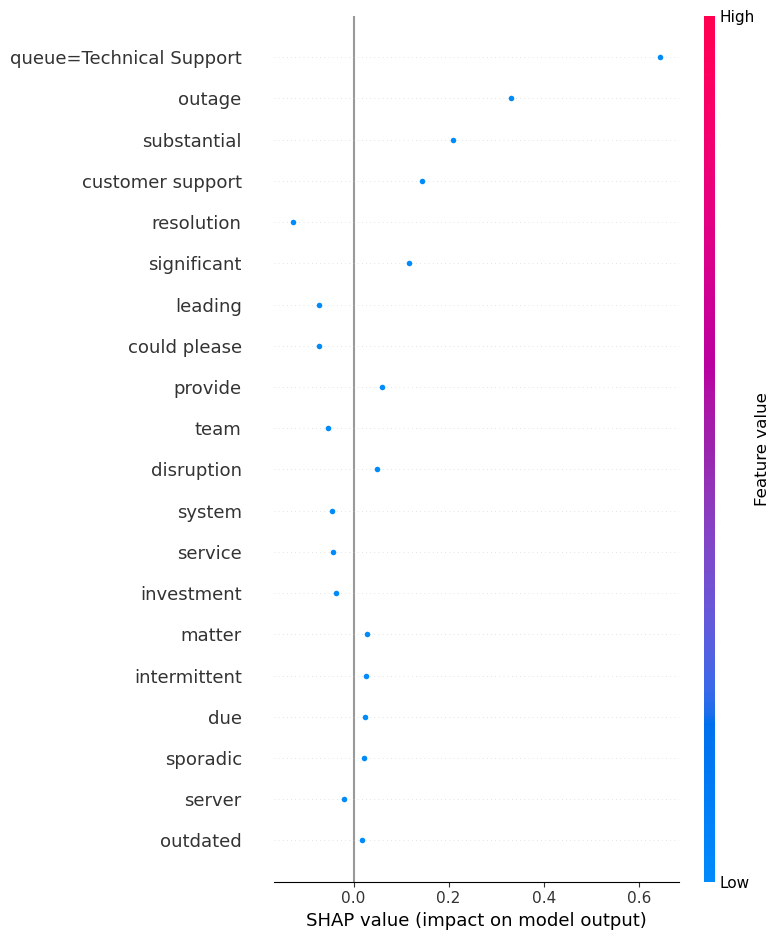

In [29]:
class_idx = 2

shap.summary_plot(
    shap_values[:, :, predicted_class],
    X_dense,
    max_display=20
)

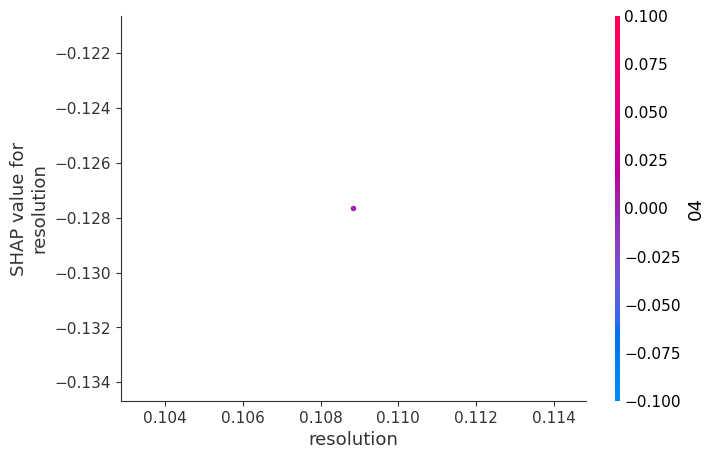

In [37]:
shap.dependence_plot(
    "resolution",
    shap_values[:, :, predicted_class],
    X_dense
)